# Final Project

This notebook is adapted from here: https://aiqm.github.io/torchani/examples/nnp_training.html

## Checkpoint 1: Data preparation

1. Create a working directory: `/global/scratch/users/[USER_NAME]/[DIR_NAME]`. Replace the [USER_NAME] with yours and specify a [DIR_NAME] you like.
2. Copy the Jupyter Notebook to the working directory
3. Download the ANI dataset `ani_dataset_gdb_s01_to_s04.h5` from bCourses and upload it to the working directory

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import matplotlib.pyplot as plt

### Use GPU

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### Set up AEV computer

#### AEV: Atomic Environment Vector (atomic features)

Ref: Chem. Sci., 2017, 8, 3192

In [3]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


### Prepare dataset & split

In [4]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("./ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8,0.1,0.1)

### Batching

In [5]:
batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()

### Torchani API

In [6]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [7]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.0861, device='cuda:0', grad_fn=<MseLossBackward0>)


# April 5 - Checkpoint 2

In [8]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                species = train_data_batch['species'].to(device)
                coords = train_data_batch['coordinates'].to(device)
                true_energies = train_data_batch['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)
                
                # do a step
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = true_energies.shape[0] / len(train_data)
                train_epoch_loss += batch_loss.detach().cpu().item()*batch_importance
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data)
            
            # append the losses
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(range(len(train_loss_list)), train_loss_list, label='Train')
            ax.plot(range(len(val_loss_list)), val_loss_list, label='Validation')
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                species = batch_data['species'].to(device)
                coords = batch_data['coordinates'].to(device)
                true_energies = batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species, coords))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies)


                batch_importance = true_energies.shape[0] / len(data)
                total_loss += batch_loss.detach().cpu().item()*batch_importance
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all - pred_energies_all))*hartree2kcalmol
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss
        

In [20]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 10/10 [00:58<00:00,  5.86s/it]


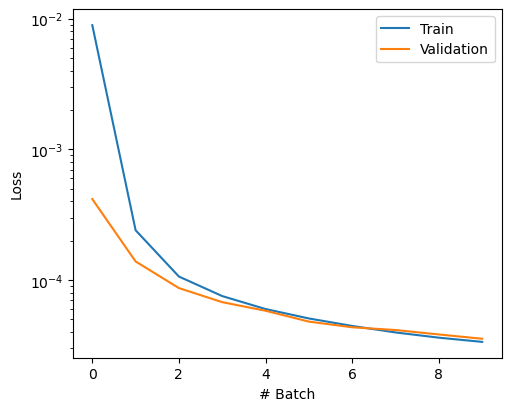

In [10]:
trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=10, l2=1e-5)
train_loss, val_loss = trainer.train(train_data, val_data)

Test MSE Loss: 0.000036


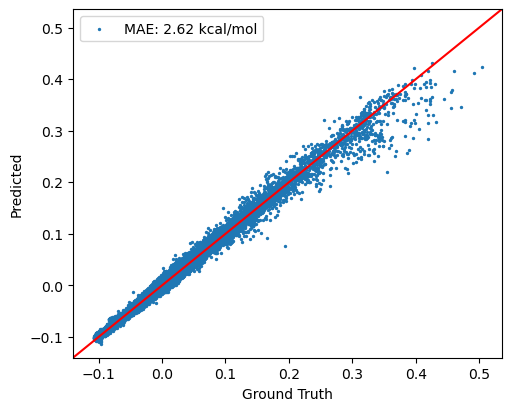

In [11]:
test_loss = trainer.evaluate(test_data, draw_plot=True)
print(f"Test MSE Loss: {test_loss:.6f}")

# April 12 - Checkpoint 3

I am trying to get MAE below 2 kcal/mol (as outlined in the guidelines). I had about 6 different attempts with this goal in mind:

Trial 1: Increasing the amount of epochs that I used for Checkpoint 2 (10 to 20).

Trial 2: I added an extra hidden layer to add capacity to the model.

Trial 3: I decreased the learning rate and increased the epochs again.

Trial 4: I did L2 regularization to see if more weight decay would help prevent overfitting.

Trial 5: I used dropout to help prevent overfitting.

Trial 6: I added even more hidden layers (3).

Trial 1:

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [01:56<00:00,  5.83s/it]


2.1425120691832998e-05

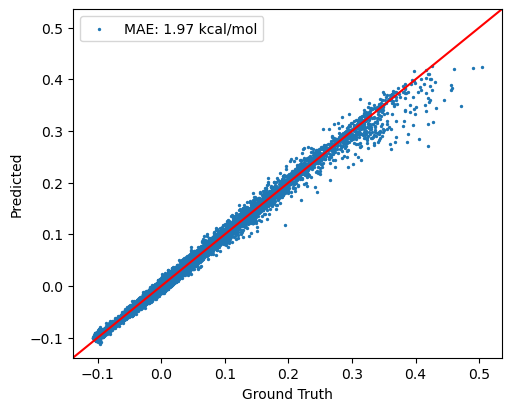

In [ ]:
net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_data, val_data, draw_curve=False)
trainer.evaluate(test_data, draw_plot=True)

Trial 2:

In [9]:
class AtomicNetDeep(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [02:07<00:00,  6.38s/it]


1.7380543917848136e-05

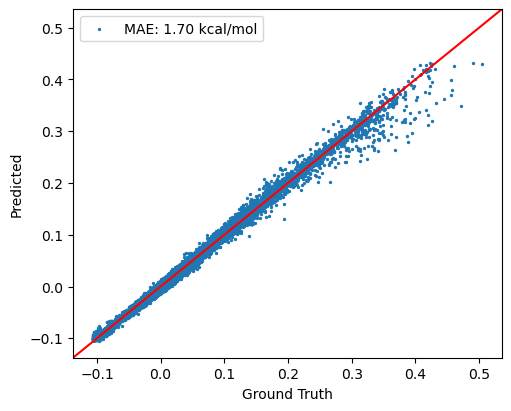

In [14]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_data, val_data, draw_curve=False)
trainer.evaluate(test_data, draw_plot=True)

Trial 3:

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 30/30 [03:11<00:00,  6.39s/it]


5.019830784827742e-05

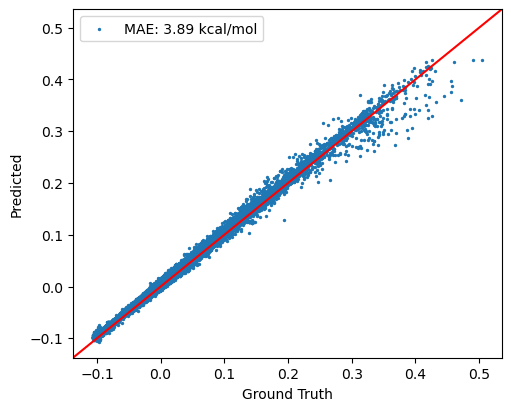

In [15]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=5e-4, epoch=30, l2=1e-5)
_ = trainer.train(train_data, val_data, draw_curve=False)
trainer.evaluate(test_data, draw_plot=True)

Trial 4:

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [02:07<00:00,  6.37s/it]


7.561423236827596e-05

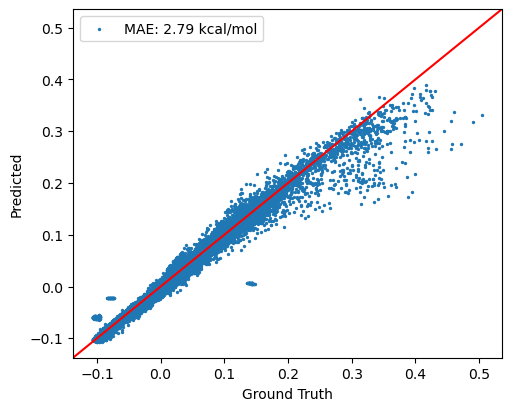

In [16]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-4)
_ = trainer.train(train_data, val_data, draw_curve=False)
trainer.evaluate(test_data, draw_plot=True)

Trial 5:

In [22]:
class AtomicNetDeepDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [02:10<00:00,  6.53s/it]


9.473782745599248e-05

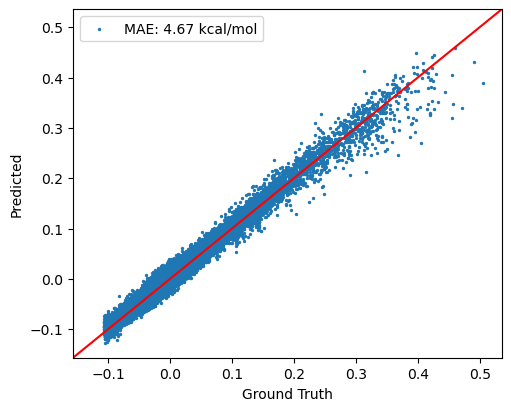

In [18]:
net_H = AtomicNetDeepDropout()
net_C = AtomicNetDeepDropout()
net_N = AtomicNetDeepDropout()
net_O = AtomicNetDeepDropout()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_data, val_data, draw_curve=False)
trainer.evaluate(test_data, draw_plot=True)

Trial 6:

In [23]:
class AtomicNet3Layer(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

Sequential - Number of parameters: 559108
Initialize training data...


100%|██████████| 20/20 [02:11<00:00,  6.59s/it]


4.612342733838703e-05

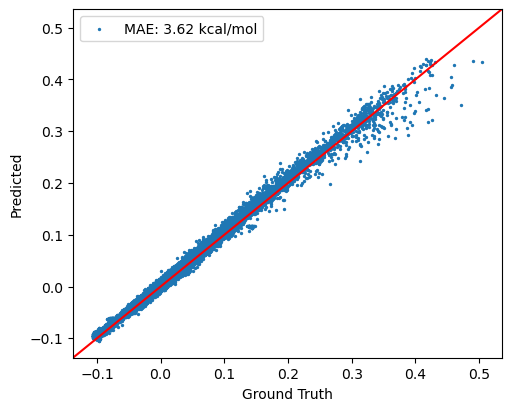

In [22]:
net_H = AtomicNet3Layer()
net_C = AtomicNet3Layer()
net_N = AtomicNet3Layer()
net_O = AtomicNet3Layer()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_data, val_data, draw_curve=False)
trainer.evaluate(test_data, draw_plot=True)

Trial 2 performed the best, with the deeper network, on average with about 1.70 kcal/mol.

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [02:11<00:00,  6.55s/it]


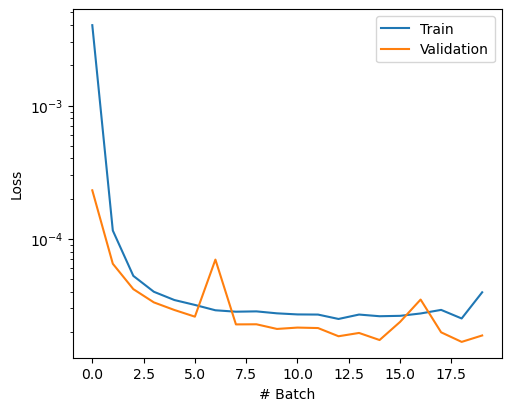

In [23]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_data, val_data, draw_curve=True)

Test MSE Loss: 0.000019


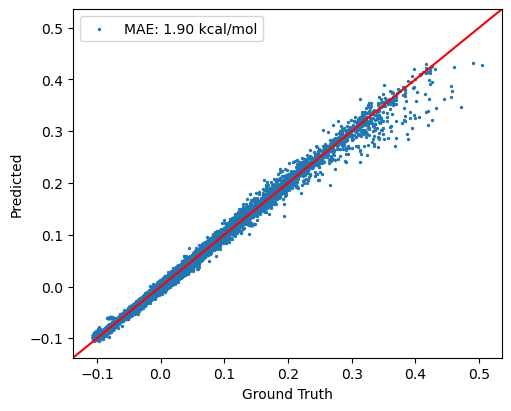

In [24]:
test_loss = trainer.evaluate(test_data, draw_plot=True)
print(f"Test MSE Loss: {test_loss:.6f}")

# Discussion of my results:

Trial 2 with the deeper network performed the best at 1.70 kcal/mol. By adding the extra hidden layer it gave the model more capacity to learn compared to the original architecture. Just by increasing the amount of epochs for Trial 1 made MAE better meaning I should probably allow for more runtime. When I Lowered the learning rate in Trial 3 it made the MAE worse (3.89), this is most likely due to 30 epochs not being enough for convergence. The stronger weight decay in Trial 4 (2.79) hurt performance. Dropout in Trial 5 performed the worst (4.67), which makes sense to me for the smaller size for the network. The 3 hidden layer network in Trial 6 (3.62) also did worse, meaning more dpeth doesn't help for the size of the dataset that we are using. Upon retraining model 2 achieved 1.90 kcal/mol, which is below the 2 kcal/mol target. After all of these trials and playing around with the hyperparameters I believe I will be going with an architecture similar to Trial 2 (deeper network with a hidden layer) and allowing for more epochs for convergence.

# April 19 - Checkpoint 4
I first need to check if I am using the right model by doing multiple runs to check how consistent it is, Then I am going to perform N-Fold cross validation to help model how well the model is performing.

Trial 1:

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [01:56<00:00,  5.81s/it]


1.837188114374738e-05

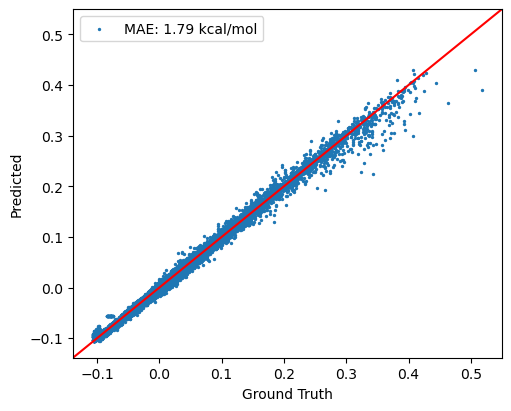

In [24]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_data, val_data, draw_curve=False)
trainer.evaluate(test_data, draw_plot=True)

Trial 2:

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [02:11<00:00,  6.55s/it]


2.6718591828661545e-05

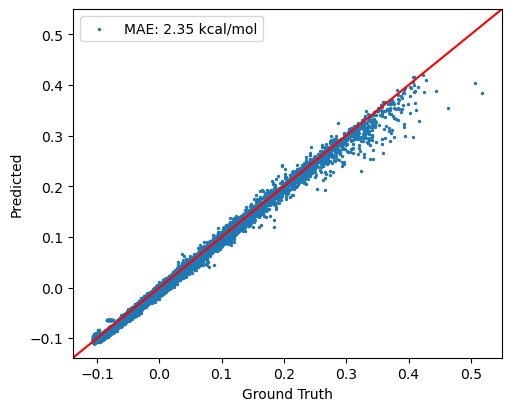

In [33]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_data, val_data, draw_curve=False)
trainer.evaluate(test_data, draw_plot=True)

Trial 3:

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [01:52<00:00,  5.64s/it]


1.801693256923793e-05

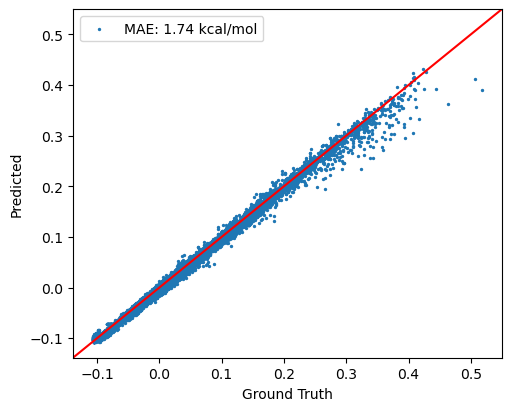

In [26]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_data, val_data, draw_curve=False)
trainer.evaluate(test_data, draw_plot=True)

For trial 1 I got an MAE of 1.79. For trial 2 I got an MAE of 2.35. For trial 3 I got an MAE of 1.74. This would make the mean equal to 1.96, and it would have a standard deviation of about 0.34. I believe this holds up well as the mean is under the target goal of under 2.00, meaning I am moving on to N-fold cross validation.

I am going to start by reloading the dataset and begin splitting it into 3 folds. 2 Folds for training and 1 fold for testing. For 3 trials I will be alternating which fold the test will be on.

In [27]:
dataset_cv = load_ani_dataset("./ani_gdb_s01_to_s04.h5")

N-Fold Trial 1: (training on folds 2 and 3, testing on 1)

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [00:53<00:00,  2.65s/it]


2.0786296068171736e-05

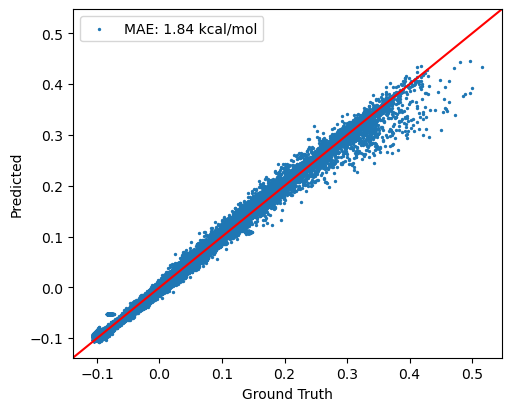

In [28]:
fold1, fold2, fold3 = dataset_cv.split(1/3, 1/3, 1/3)

train_fold1, val_fold1 = fold2.split(0.85, 0.15)

net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

train_f1, val_f1 = fold3.split(0.85, 0.15)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_f1, val_f1, draw_curve=False)
trainer.evaluate(fold1, draw_plot=True)

N-Fold Trial 2: (training on folds 1 and 3, testing on 2)

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [00:53<00:00,  2.69s/it]


2.8284785431440405e-05

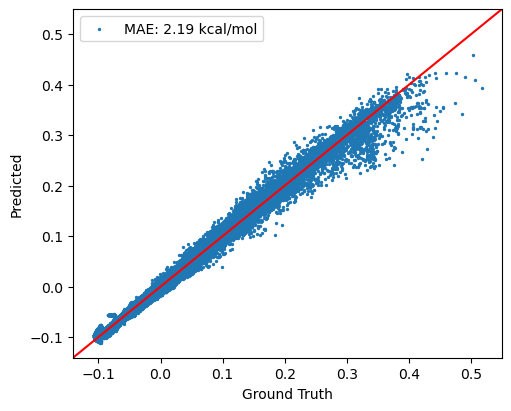

In [29]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

train_f2, val_f2 = fold1.split(0.85, 0.15)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_f2, val_f2, draw_curve=False)
trainer.evaluate(fold2, draw_plot=True)

N-Fold Trial 3: (training on folds 1 and 2, testing on 3)

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [00:54<00:00,  2.72s/it]


2.271844487544867e-05

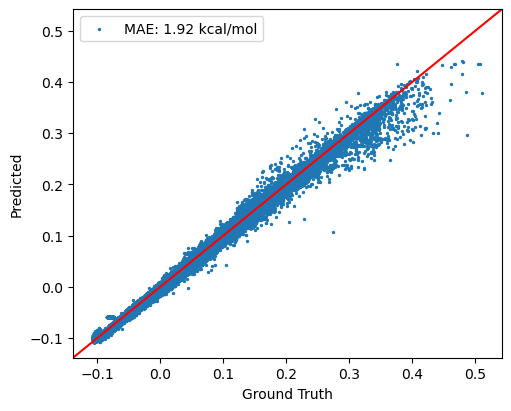

In [30]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

train_f3, val_f3 = fold2.split(0.85, 0.15)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
_ = trainer.train(train_f3, val_f3, draw_curve=False)
trainer.evaluate(fold3, draw_plot=True)

For N-fold trial 1 I got an MAE of 1.84. For trial 2 I got an MAE of 2.19. For trial 3 I got an MAE of 1.92. This would make the mean equal to 1.98, and it would have a standard deviation of about 0.18. I believe this holds up well as the mean is under the target goal of under 2.00, meaning I am moving on to my final run with an 80/10/10 split.

Final Run:

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [02:05<00:00,  6.29s/it]


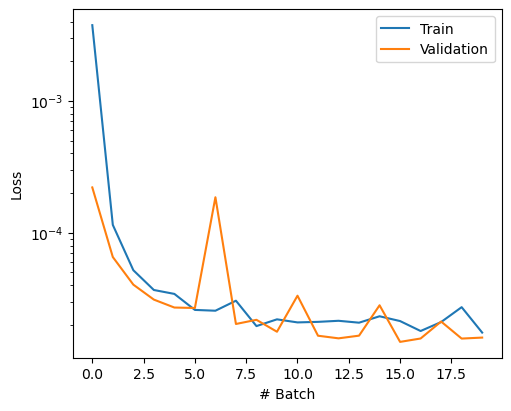

In [34]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
train_loss, val_loss = trainer.train(train_data, val_data, draw_curve=True)

Test MSE Loss: 0.000016


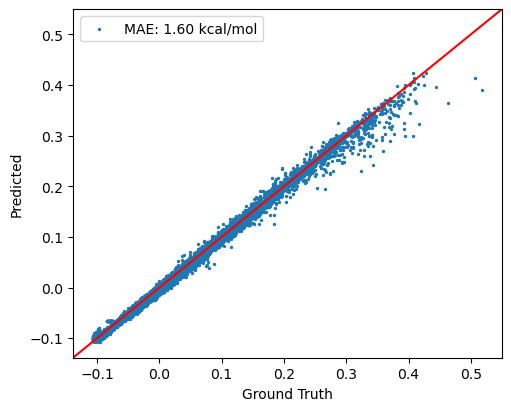

In [35]:
test_loss = trainer.evaluate(test_data, draw_plot=True)
print(f"Test MSE Loss: {test_loss:.6f}")

# Discussion of my results:

The multiple trials show that my model averages about 1.96 kcal/mol with some variance (0.34) from what I assume is random initialization (My second trial had a way higher MAE at 2.35 kcal/mol). My 3-fold cross-validation trials gave a mean of 1.98 kcal/mol with a lower variance (0.18), which confirms that my model can generalize well across different data splits. My final run achieved 1.60 kcal/mol, which is well below the 2 kcal/mol goal. My learning curve shows some noise in the training loss, but the validation loss stays low, early stopping picks the best weights, and overall my parity plot looks good.

# April 26 - Checkpoint 5

For the last checkpoint I am going to retrain my best model one more time using my final hyperparameters (AtomicNetDeep, lr=1e-3, epoch=20, l2=1e-5) on the full training set and then break down the test errors by number of heavy atoms in each molecule. The dataset ani_gdb_s01_to_s04 contains molecules with 1, 2, 3, or 4 heavy atoms (C, N, O), so this lets me see how the model performs across different molecule sizes. I will then compare my results to what the ANI-1 paper reports.

Final Model:

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [01:44<00:00,  5.22s/it]


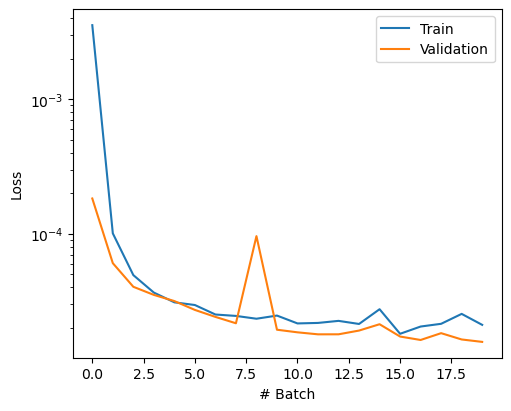

In [11]:
net_H = AtomicNetDeep()
net_C = AtomicNetDeep()
net_N = AtomicNetDeep()
net_O = AtomicNetDeep()
ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
model = nn.Sequential(aev_computer, ani_net).to(device)

trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
train_loss, val_loss = trainer.train(train_data, val_data, draw_curve=True)

Test MSE Loss: 0.000016


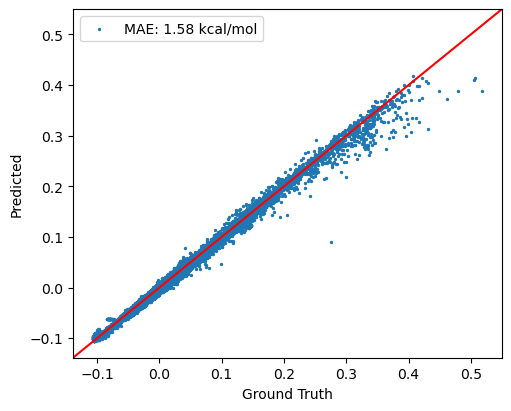

In [12]:
test_loss = trainer.evaluate(test_data, draw_plot=True)
print(f"Test MSE Loss: {test_loss:.6f}")

### Breakdown of errors by number of heavy atoms
Heavy atoms are anything that isn't H. In my species labels, 0=H, 1=C, 2=N, 3=O,
and -1 is padding. So heavy atoms are species values greater than 0. I am going to
loop through the test set, count the heavy atoms per molecule, and then compute the
MAE separately for molecules with 1, 2, 3, and 4 heavy atoms.

In [ ]:
model.eval()
test_loader = test_data.collate(8192).cache()

mae_by_heavy = {1: [], 2: [], 3: [], 4: []}

with torch.no_grad():
    for batch_data in test_loader:
        species = batch_data['species'].to(device)
        coords = batch_data['coordinates'].to(device)
        true_energies = batch_data['energies'].to(device).float()
        _, pred_energies = model((species, coords))
        
        for i in range(species.shape[0]):
            n_heavy = 0
            for atom in species[i]:
                if atom > 0:
                    n_heavy += 1
            
            error = abs(true_energies[i].item() - pred_energies[i].item())
            if n_heavy in mae_by_heavy:
                mae_by_heavy[n_heavy].append(error)

hartree2kcalmol = 627.5094738898777
print("Test MAE broken down by number of heavy atoms:")
for n in [1, 2, 3, 4]:
    errors = mae_by_heavy[n]
    if len(errors) > 0:
        mae_n = np.mean(errors) * hartree2kcalmol
        print(f"  {n} heavy atoms: {len(errors)} molecules, MAE = {mae_n:.2f} kcal/mol")

Test MAE broken down by number of heavy atoms:
  1 heavy atoms: 1052 molecules, MAE = 1.59 kcal/mol
  2 heavy atoms: 5087 molecules, MAE = 3.07 kcal/mol
  3 heavy atoms: 15176 molecules, MAE = 1.56 kcal/mol
  4 heavy atoms: 65174 molecules, MAE = 1.47 kcal/mol


### Bar chart

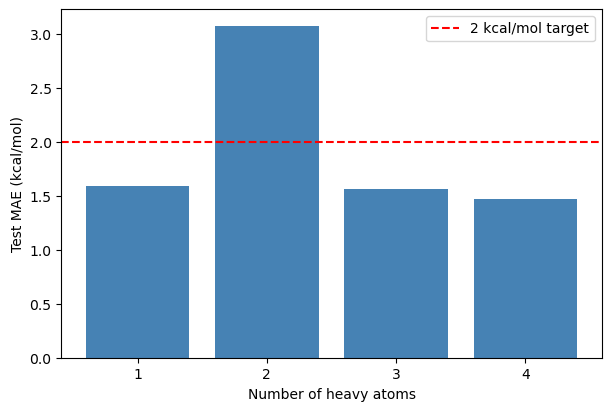

In [16]:
heavy_counts = [1, 2, 3, 4]
maes = []
for n in heavy_counts:
    errors = mae_by_heavy[n]
    mae_n = np.mean(errors) * hartree2kcalmol
    maes.append(mae_n)

fig, ax = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)
ax.bar(heavy_counts, maes, color='steelblue')
ax.axhline(y=2.0, color='red', linestyle='--', label='2 kcal/mol target')
ax.set_xlabel("Number of heavy atoms")
ax.set_ylabel("Test MAE (kcal/mol)")
ax.set_xticks(heavy_counts)
ax.legend()
plt.show()

### Heavy atom breakdown

| # Heavy atoms | # Molecules in test | MAE (kcal/mol) |
|---------------|---------------------|----------------|
| 1             | 1,052                 | 1.59            |
| 2             | 5,089                 | 3.07            |
| 3             | 15,176                 | 1.56            |
| 4             | 65,174                 | 1.47            |
| Overall             | 86,489                 | 1.58            |

My results how a breakdown where MAE is consistent for 1, 3, and 4 heavy atom molecules, but jumps to 3.07 kcal/mol for 2 heavy atom molecules. This is sort of an outlier since 2 heavy atom molecules should be easier than 4. It might be due to a smaller and less unique subset of 2-heavy-atom molecules in the Ani dataset, making it harder for my model to generalize to that specific size class. The bulk of the test set is 4-heavy-atom molecules which the model handles well at 1.47 kcal/mol, which is why the overall MAE of 1.58 stayed below my 2 kcal/mol target.

### Comparison of my Model to the ANI-1 paper

| Quantity | ANI-1 Paper | My Model |
|----------|------------|-----------|
| Training conformations | 17 million | 692k |
| Heavy atoms covered | 1-8 | 1-4 |
| Architecture | 768:128:128:64:1 (4 hidden) | 384:256:128:1 (2 hidden) |
| Activation | Gaussian | ReLU |
| Test RMSE/MAE | 1.3 kcal/mol | 1.58 kcal/mol |

My test MAE is close to the paper's test RMSE of 1.3 kcal/mol. My results are generally in the same ballpark as the paper despite training
on a much smaller dataset and a simpler network, which makes sense because the s01-s04 molecules are easier to work with.

## My Final Conclusions

Across all five checkpoints I built and trained an ANI neural network potential on the ANI dataset. In checkpoint 1 I loaded the data and did the 80/10/10 split with batching. In checkpoint 2 I made the ANITrainer class and got a baseline MAE of 2.13. For checkpoint 3 I tried 6 different hyperparameter configurations and the best one got 1.70. In checkpoint 4 I did multiple runs and 3-fold cross-validation to make sure the results were consistent (mean around 1.96 with std 0.34 for multiple runs, 1.98 with std 0.18 for cross-validation). My final run for chekcpoint 4 was 1.60 kcal/mol. My final model achieved a test MAE of 1.58 kcal/mol which is below the overall 2 kcal/mol goal. The deeper [384, 256, 128, 1] architecture with lr=1e-3, L2=1e-5, and 20 epochs ended up working the best for my model. Adding more layers, dropout, or stronger weight decay all hurt performance, and lowering the learning rate without enough epochs hurt it too. Compared to the ANI-1 paper which got 1.3 kcal/mol RMSE, my MAE is in a similar range but a bit higher, which makes sense since they trained on way more data (17 million vs 692 thousand) and they used a deeper network. One last thing for me to keep in mind is that my model probably wouldn't work for molecules with more than 4 heavy atoms since it never saw them.